In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


In [ ]:
(train_images, train_label), (test_images, test_label) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


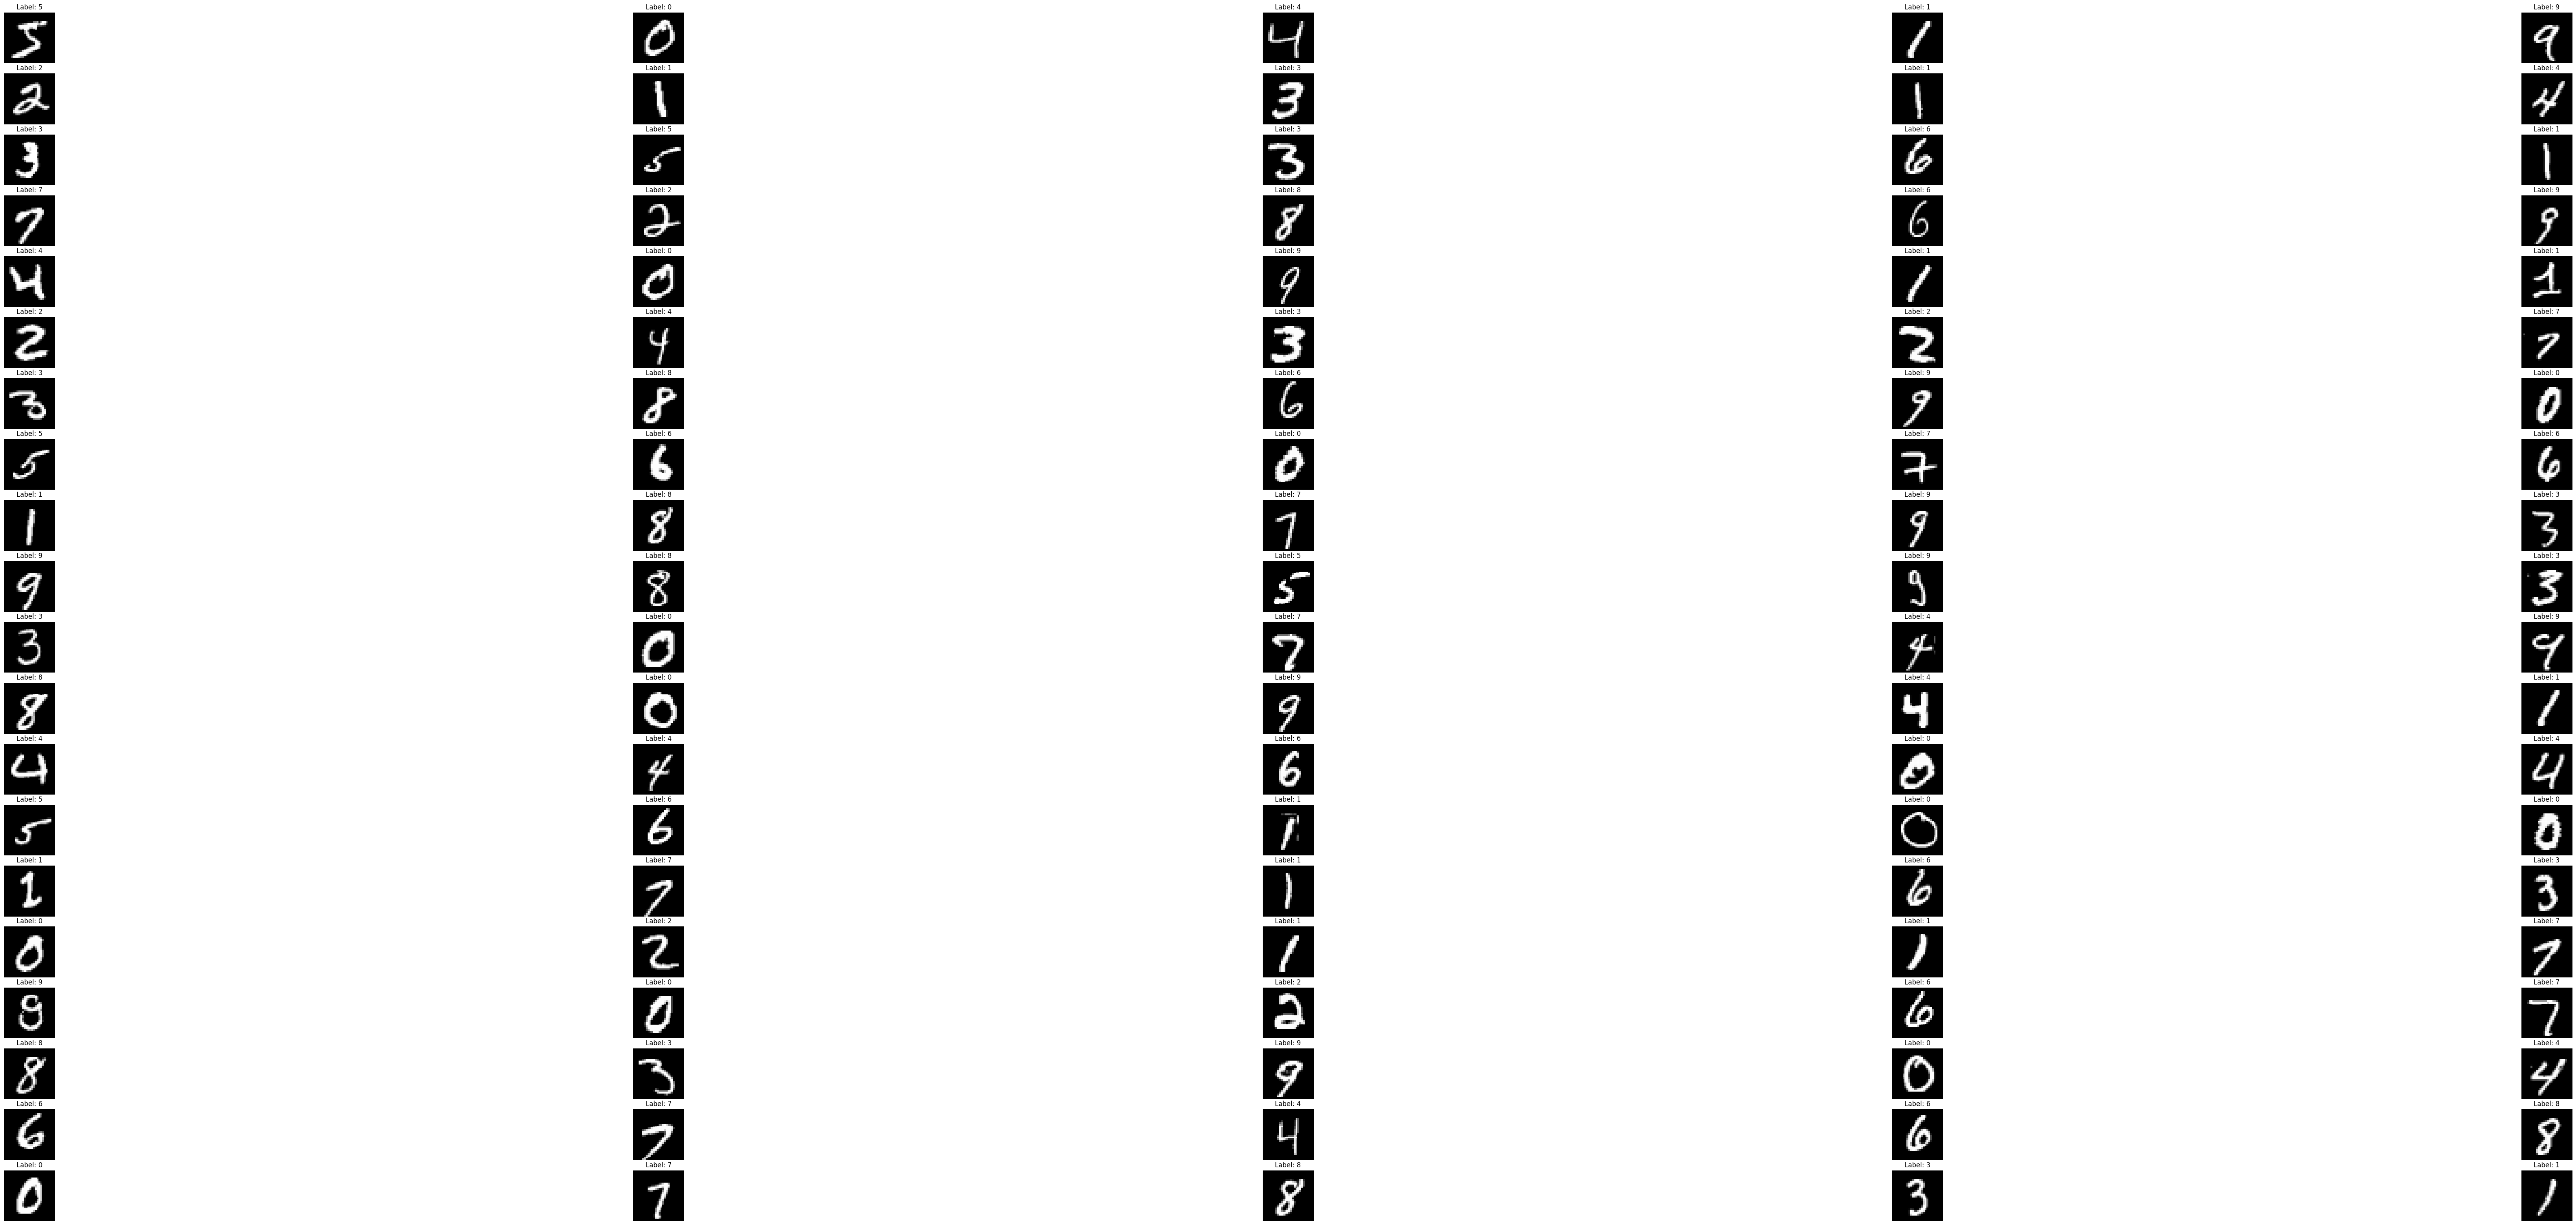

In [ ]:
plt.figure(figsize=(100,40))
for i in range(100):
  plt.subplot(20,5,i+1)
  plt.imshow(train_images[i], cmap='gray')
  plt.title(f"Label: {train_label[i]}")
  plt.axis('off')
plt.show()

In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
train_images = train_images.reshape((60000,28,28,1))
test_images = test_images.reshape((10000,28,28,1))

In [ ]:
model=models.Sequential()

Convolution Layer

In [ ]:
model.add(layers.Conv2D(32, (3,3),
                        activation='relu',input_shape=(28,28,1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Pooling Layer

In [ ]:
model.add(layers.MaxPooling2D((2,2)))

Another Conv Layer

In [ ]:
model.add(layers.Conv2D(64, (3,3), activation='relu'))

Another Pooling

In [ ]:
model.add(layers.MaxPooling2D((2,2)))

Flatten

In [ ]:
model.add(layers.Flatten())

Fully Connected layer

In [ ]:
model.add(layers.Dense(64, activation='relu'))

Output Layer

In [ ]:
model.add(layers.Dense(10, activation='softmax'))

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(train_images, train_label, epochs=5,
                    validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 31ms/step - accuracy: 0.9254 - loss: 0.2481 - val_accuracy: 0.9777 - val_loss: 0.0717
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9742 - loss: 0.0832 - val_accuracy: 0.9820 - val_loss: 0.0655
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9809 - loss: 0.0610 - val_accuracy: 0.9830 - val_loss: 0.0538
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9841 - loss: 0.0505 - val_accuracy: 0.9763 - val_loss: 0.0793
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9864 - loss: 0.0427 - val_accuracy: 0.9853 - val_loss: 0.0468


In [ ]:
tst_loss, test_acc = model.evaluate(test_images, test_label)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9850 - loss: 0.0506
Test Accuracy: 0.9850000143051147


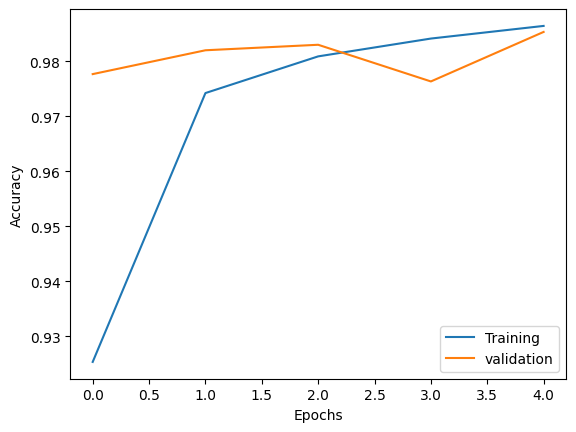

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training', 'validation'])
plt.show()

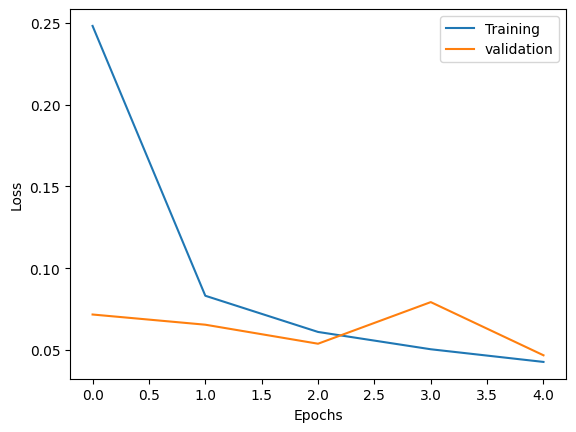

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training', 'validation'])
plt.show()